# English -> {Hindi, Bengali}: one multilingual Transformer, trained from scratch

A single encoder-decoder serves both directions. The target language is selected by a
tag token (`<2hi>` / `<2bn>`) prepended to the encoder input, following Johnson et al.
2017 ([arXiv:1611.04558](https://arxiv.org/abs/1611.04558)).

**Why one model and not a router.** The source side of this corpus is always English, so a
language detector reading the input cannot tell you whether Hindi or Bengali is wanted --
that is target-side metadata, and `val_data1.json` already supplies it as a top-level key.
With only ~140k pairs, sharing one encoder across both directions gives the English side
twice the data, and Hindi and Bengali share enough Sanskrit-derived vocabulary for the
decoder to transfer too.

**Run order.** Gates first. They take about two minutes and catch the failure modes
(token-id mismatch, collapsed vocabulary) that silently wasted entire training runs on
this dataset before.

Transformer implemented from scratch in `src/model.py` -- no `nn.Transformer`, no
`nn.MultiheadAttention`, no pretrained weights.

## 1. Environment and data

In [1]:
!nvidia-smi

# torch is preinstalled on Colab. sentencepiece and pyyaml are the only hard
# requirements; sacrebleu and nltk are optional and used solely by
# `score.py --cross-check`.
!pip -q install sentencepiece pyyaml sacrebleu nltk
import nltk; nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)

import torch
print('torch', torch.__version__, '| cuda', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU')

Mon Aug 24 23:23:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Code and data live on the VM's local disk (fast). Checkpoints go to Drive, so a
# session timeout costs at most one eval interval.
#
# Re-run this cell after any disconnect: ~30 seconds, and it restores the whole
# working tree. Nothing under /content survives a restart; nothing under
# SAVE_DIR is lost by one.
!cp /content/drive/MyDrive/capstone-mt-upload.zip /content/
!cd /content && unzip -q -o capstone-mt-upload.zip

PROJECT  = '/content/capstone-mt'
SAVE_DIR = '/content/drive/MyDrive/capstone-mt-runs/base'

import os, sys
os.makedirs(SAVE_DIR, exist_ok=True)
os.chdir(PROJECT)
sys.path.insert(0, PROJECT + '/src')
print(os.getcwd(), sorted(os.listdir('.')))
print('checkpoints ->', SAVE_DIR)

Mounted at /content/drive
/content/capstone-mt ['README.md', 'configs', 'data', 'evaluate.py', 'notebooks', 'requirements.txt', 'src', 'val_data1.json']
checkpoints -> /content/drive/MyDrive/capstone-mt-runs/base


### Data preparation and tokenizer

**Required** — the upload bundle carries only the raw corpora, so `data/clean/`,
`dicts/` and `spm/joint16k.model` are built here. About two minutes total, fully
deterministic, and it keeps ~240 MB of derived artefacts out of Drive.

Re-run after every reconnect (it is part of restoring `/content`).

In [3]:
!python src/lid.py
!python src/data_prep.py
!python src/tokenizer.py --vocab-size 16000
!cat data/clean/report.json

train=58000  holdout=2000
holdout accuracy: 1998/2000 = 0.9990
errors (true -> predicted):
  hi -> en: 2
saved -> /content/capstone-mt/dicts/lid_charngram.json
loaded LID model from /content/capstone-mt/dicts/lid_charngram.json
[en_bn/train] read=65407 kept=64676
[en_bn/dev] read=1721 kept=1717
[en_bn/test] read=1721 kept=1716
[en_bn/train] after de-leak: 64359
[en_hi/train] read=76759 kept=75723
[en_hi/dev] read=2019 kept=2011
[en_hi/test] read=2019 kept=2001
[en_hi/train] after de-leak: 75607
[combined/train] 139966 pairs
[combined/dev] 3728 pairs
[combined/test] 3717 pairs
[spm] wrote 279932 lines -> /content/capstone-mt/data/clean/spm_input.txt
[tm] tm_train: 137614 entries -> /content/capstone-mt/dicts/tm_train.json
[tm] tm_all: 145044 entries -> /content/capstone-mt/dicts/tm_all.json
[tm] English-Bengali: 654/9836 (6.65%) exact hits
[tm] English-Hindi: 443/11543 (3.84%) exact hits

report -> /content/capstone-mt/data/clean/report.json
training unigram vocab=16000 on /content/caps

## 2. Verification gates -- do not skip

G4 is the one that matters: it trains a small model on 64 sentence pairs until it has
memorised them, then checks that greedy *and* beam-5 decoding reproduce those exact
targets. If any link in the tokenizer -> dataset -> model -> loss -> decoder chain is
wrong, this fails in about a minute rather than after six hours of GPU time.

**If anything fails here, stop and fix it. Do not start training.**

In [ ]:
!python src/gates.py

[PASS] G2 pad_id -- 0 (expect 0)
[PASS] G2 unk_id -- 1 (expect 1)
[PASS] G2 bos_id -- 2 (expect 2)
[PASS] G2 eos_id -- 3 (expect 3)
[PASS] G2 vocab size -- 16000 (expect 16000)
[PASS] G2 tag <2hi> -- id=4
[PASS] G2 tag <2bn> -- id=5
------------------------------------------------------------------
[PASS] G1 round-trip en_bn -- 2000/2000 exact = 1.0000
[PASS] G1 round-trip en_hi -- 2000/2000 exact = 1.0000
------------------------------------------------------------------
[PASS] G3 unk rate train -- 0/248416 = 0.00000
[PASS] G3 unk rate dev -- 0/182987 = 0.00000
[PASS] G3 unk rate val/English-Bengali -- 0/117605 = 0.00000
[PASS] G3 unk rate val/English-Hindi -- 0/118625 = 0.00000
------------------------------------------------------------------
[PASS] G6 self-BLEU == 1 -- 1.000000
[PASS] G6 self-ROUGE == 1 -- 1.000000
[PASS] G6 self-chrF == 1 -- 1.000000
[PASS] G6 shifted-BLEU ~ 0 -- 0.046383
------------------------------------------------------------------
     (G4 device: cuda)
   

## 3. Train

`--resume auto` picks up the newest checkpoint in `--save-dir`, so re-running this cell
after a disconnect continues rather than restarting. Roughly 4-6 hours to 40k steps on a
T4; a decode probe prints real translations at every eval so collapse is visible early.

In [ ]:
!python src/train.py \
  --config configs/base.yaml \
  --save-dir "$SAVE_DIR" \
  --resume auto

device: cuda
vocab: 16000
train pairs: 139966   dev pairs: 3728
parameters: 52.3M
resumed from /content/drive/MyDrive/capstone-mt-runs/base/step18000.pt at step 18000, best dev 3.1991
training to 40000 steps (accum=3, ~24000 tokens/update)
step  18100 | train 2.6406 | ppl    14.02 | lr 3.28e-04 | 1.5m
step  18200 | train 2.6997 | ppl    14.88 | lr 3.28e-04 | 3.1m
step  18300 | train 2.6441 | ppl    14.07 | lr 3.27e-04 | 4.6m
step  18400 | train 2.6730 | ppl    14.48 | lr 3.26e-04 | 6.1m
step  18500 | train 2.6571 | ppl    14.26 | lr 3.25e-04 | 7.7m
step  18600 | train 2.6713 | ppl    14.46 | lr 3.24e-04 | 9.2m
step  18700 | train 2.6431 | ppl    14.06 | lr 3.23e-04 | 10.7m
step  18800 | train 2.6659 | ppl    14.38 | lr 3.22e-04 | 12.3m
step  18900 | train 2.6630 | ppl    14.34 | lr 3.21e-04 | 13.8m
step  19000 | train 2.6363 | ppl    13.96 | lr 3.21e-04 | 15.4m
step  19100 | train 2.6484 | ppl    14.13 | lr 3.20e-04 | 16.9m
step  19200 | train 2.6547 | ppl    14.22 | lr 3.19e-04 | 18.5

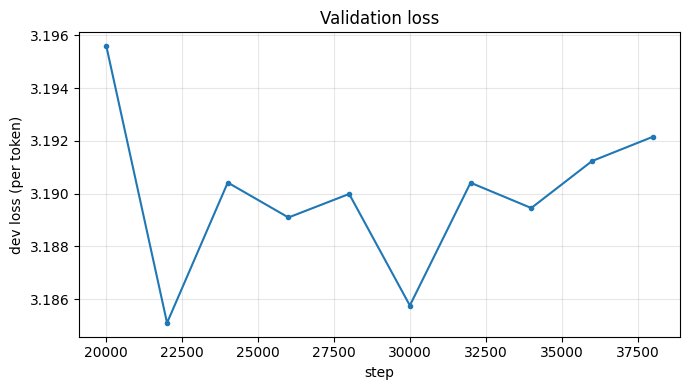

In [ ]:
# Loss curve
import json, matplotlib.pyplot as plt
h = json.load(open(SAVE_DIR + '/history.json'))
plt.figure(figsize=(7, 4))
plt.plot([x['step'] for x in h], [x['dev_loss'] for x in h], marker='o', ms=3)
plt.xlabel('step'); plt.ylabel('dev loss (per token)'); plt.grid(alpha=.3)
plt.title('Validation loss'); plt.tight_layout(); plt.show()

## 4. Decode and score the dev set

`val_data1.json` has no references, so every number that guides a decision comes from
`data/clean/combined/dev.tsv`. Averaging the last few checkpoints is worth a little for
almost no cost. `--verify-cache` re-checks that incremental decoding matches the
uncached path on this specific model.

In [4]:
!python src/decode.py \
  --save-dir "$SAVE_DIR" --average-last 5 \
  --input data/clean/combined/dev.tsv \
  --out outs/dev.hyp \
  --beam 5 --alpha 0.6 --batch-size 64 --verify-cache

!python src/score.py --hyp outs/dev.hyp --ref data/clean/combined/dev.tsv \
  --cross-check --out outs/dev.scores.json

device: cuda
averaging: ['step30000.pt', 'step32000.pt', 'step34000.pt', 'step36000.pt', 'step38000.pt']
averaged 5 checkpoints
3728 sentences to translate
[PASS] cache verification: 16/16 identical
  1280/3728  0.2m  (86.3/s, eta 0.5m)
  2560/3728  0.7m  (57.8/s, eta 0.3m)
  3728/3728  1.8m  (34.9/s, eta 0.0m)
wrote /content/capstone-mt/outs/dev.hyp
{
  "overall": {
    "bleu": 0.5445,
    "rouge_l": 0.6525,
    "chrf": 0.5014,
    "total": 1.698,
    "n": 3728
  },
  "bn": {
    "bleu": 0.5109,
    "rouge_l": 0.6279,
    "chrf": 0.4585,
    "total": 1.597,
    "n": 1717
  },
  "hi": {
    "bleu": 0.5717,
    "rouge_l": 0.6735,
    "chrf": 0.5321,
    "total": 1.777,
    "n": 2011
  },
  "cross_check": {
    "sacrebleu_bleu_x100": 27.022,
    "sacrebleu_chrf++_x100": 50.526,
    "nltk_bleu": 0.2672
  }
}

wrote outs/dev.scores.json


### Beam / length-penalty sweep

Cheap relative to training and usually worth a point or so. Pick on dev, then use the
winner for the submission.

In [5]:
import json, subprocess
rows = []
for beam in (1, 4, 5, 8):
    for alpha in (0.0, 0.6, 1.0):
        if beam == 1 and alpha != 0.0:
            continue  # length penalty is meaningless for greedy
        tag = f'b{beam}_a{alpha}'
        subprocess.run(['python', 'src/decode.py', '--save-dir', SAVE_DIR,
                        '--average-last', '5', '--input', 'data/clean/combined/dev.tsv',
                        '--out', f'outs/dev.{tag}.hyp', '--beam', str(beam),
                        '--alpha', str(alpha), '--batch-size', '64'], check=True)
        subprocess.run(['python', 'src/score.py', '--hyp', f'outs/dev.{tag}.hyp',
                        '--ref', 'data/clean/combined/dev.tsv',
                        '--out', f'outs/dev.{tag}.json'], check=True)
        s = json.load(open(f'outs/dev.{tag}.json'))['overall']
        rows.append((beam, alpha, s['bleu'], s['rouge_l'], s['chrf'], s['total']))

print(f"{'beam':>5} {'alpha':>6} {'BLEU':>8} {'ROUGE-L':>8} {'chrF':>8} {'total':>8}")
for r in sorted(rows, key=lambda x: -x[5]):
    print(f'{r[0]:>5} {r[1]:>6} {r[2]:>8.4f} {r[3]:>8.4f} {r[4]:>8.4f} {r[5]:>8.4f}')

 beam  alpha     BLEU  ROUGE-L     chrF    total
    5    1.0   0.5458   0.6526   0.5021   1.7010
    8    1.0   0.5459   0.6529   0.5024   1.7010
    4    1.0   0.5459   0.6525   0.5021   1.7000
    4    0.6   0.5450   0.6525   0.5016   1.6990
    5    0.6   0.5445   0.6525   0.5014   1.6980
    8    0.6   0.5441   0.6529   0.5014   1.6980
    4    0.0   0.5432   0.6520   0.5004   1.6950
    5    0.0   0.5421   0.6516   0.4997   1.6940
    8    0.0   0.5412   0.6516   0.4993   1.6920
    1    0.0   0.5418   0.6476   0.4983   1.6880


## 5. Translate the validation set and build the submission

21,379 sentences; expect roughly 30-45 minutes at beam 5 on a T4. `make_submission.py`
applies the exact-match translation memory (about 5% of validation sources appear
verbatim in training data) and asserts the id set and row count before writing.

In [6]:
!python src/decode.py \
  --save-dir "$SAVE_DIR" --average-last 5 \
  --val-json --out outs/val_hyps.json \
  --beam 5 --alpha 0.6 --batch-size 64

!python src/make_submission.py --hyps outs/val_hyps.json --out submission/answer.csv
!head -3 submission/answer.csv

# /content is wiped on restart -- copy anything you care about back to Drive.
import shutil, os
os.makedirs(SAVE_DIR + '/artifacts', exist_ok=True)
for f in ['submission/answer.csv', 'outs/val_hyps.json',
          'outs/dev.hyp', 'outs/dev.scores.json', 'data/clean/report.json']:
    if os.path.exists(f):
        shutil.copy(f, SAVE_DIR + '/artifacts/' + os.path.basename(f))
print('saved to', SAVE_DIR + '/artifacts:', sorted(os.listdir(SAVE_DIR + '/artifacts')))

device: cuda
averaging: ['step30000.pt', 'step32000.pt', 'step34000.pt', 'step36000.pt', 'step38000.pt']
averaged 5 checkpoints
21379 sentences to translate
  1280/21379  0.1m  (169.9/s, eta 2.0m)
  2560/21379  0.3m  (149.6/s, eta 2.1m)
  3840/21379  0.5m  (133.1/s, eta 2.2m)
  5120/21379  0.7m  (118.0/s, eta 2.3m)
  6400/21379  1.0m  (103.6/s, eta 2.4m)
  7680/21379  1.3m  (95.5/s, eta 2.4m)
  8960/21379  1.7m  (87.7/s, eta 2.4m)
  10240/21379  2.1m  (80.3/s, eta 2.3m)
  11520/21379  2.6m  (74.3/s, eta 2.2m)
  12800/21379  3.1m  (68.9/s, eta 2.1m)
  14080/21379  3.7m  (64.2/s, eta 1.9m)
  15360/21379  4.3m  (60.0/s, eta 1.7m)
  16640/21379  5.0m  (55.9/s, eta 1.4m)
  17920/21379  5.7m  (51.9/s, eta 1.1m)
  19200/21379  6.7m  (47.5/s, eta 0.8m)
  20480/21379  8.0m  (42.7/s, eta 0.4m)
  21379/21379  9.7m  (36.9/s, eta 0.0m)
wrote /content/capstone-mt/outs/val_hyps.json
translation memory: 145044 entries
  English-Bengali: 9836 rows
  English-Hindi: 11543 rows
translation-memory hits: 10

## 6. Ablations

The first is the interesting one: it directly tests the central design claim, that one
shared model beats two per-language models at this data scale. Train two single-language
models on the same budget and compare dev scores against the joint model above.

In [7]:
# Ablation A -- separate models per direction (the alternative to the tag token).
!mkdir -p data/clean/only_hi data/clean/only_bn
!grep '^<2hi>' data/clean/combined/train.tsv > data/clean/only_hi/train.tsv
!grep '^<2hi>' data/clean/combined/dev.tsv   > data/clean/only_hi/dev.tsv
!grep '^<2bn>' data/clean/combined/train.tsv > data/clean/only_bn/train.tsv
!grep '^<2bn>' data/clean/combined/dev.tsv   > data/clean/only_bn/dev.tsv
!wc -l data/clean/only_hi/*.tsv data/clean/only_bn/*.tsv

# Then copy configs/base.yaml, point data.train/data.dev at one of these
# directories, and train with the same max_steps for a like-for-like comparison.

    2011 data/clean/only_hi/dev.tsv
   75607 data/clean/only_hi/train.tsv
    1717 data/clean/only_bn/dev.tsv
   64359 data/clean/only_bn/train.tsv
  143694 total


In [8]:
# Ablation B -- word2vec initialisation of the (tied) embedding table.
# Trained on our own SentencePiece-tokenised corpus rather than GloVe: it covers
# all three languages, is in-domain, and needs no external data.
!pip -q install gensim
import sentencepiece as spm
from gensim.models import Word2Vec
import torch

sp = spm.SentencePieceProcessor(model_file='spm/joint16k.model')
sents = [sp.encode(l.rstrip('\n'), out_type=str)
         for l in open('data/clean/spm_input.txt', encoding='utf-8')]
w2v = Word2Vec(sents, vector_size=512, window=5, min_count=1, sg=1, workers=4, epochs=5)

emb = torch.empty(sp.get_piece_size(), 512).normal_(0, 512 ** -0.5)
hits = 0
for i in range(sp.get_piece_size()):
    piece = sp.id_to_piece(i)
    if piece in w2v.wv:
        emb[i] = torch.tensor(w2v.wv[piece]); hits += 1
print(f'coverage: {hits}/{sp.get_piece_size()} = {hits / sp.get_piece_size():.3f}')
torch.save(emb, 'dicts/w2v_init.pt')

# Load into Transformer.embed.weight before training to compare against random init.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 33.4 MB/s eta 0:00:00
coverage: 15738/16000 = 0.984
